
## Loan Curtailment & Sensitivity Analysis

### 1. Actuarial Theory: The Retrospective Method
In actuarial mathematics, valuing a loan after an unexpected cash flow (like an early repayment or "curtailment") does not require recalculating the entire schedule from period zero. Instead, we use the **Retrospective Method** or rely on the commutativity of present/future values.

When a borrower makes a lump-sum prepayment $C$ at time $t_c$, the new outstanding balance $OL^*_{t}$ at any future time $t$ (where $t \ge t_c$) is the original outstanding balance minus the accumulated value (Future Value) of the prepayment:

$$OL^*_{t} = OL_{t} - C \cdot (1+i)^{t - t_c}$$

The loan is fully amortized when $OL^*_{t} \le 0$. This elegant mathematical relationship allows us to fully vectorize the impact of prepayments without recursive `while` loops, operating in $O(1)$ vectorized time rather than $O(n)$ iterative time.

### 2. Real-World Application
**Context:** Retail banking and consumer FinTech in Kenya (e.g., NCBA Loop, KCB M-Pesa, or Device Financing Corp).

**Business Problem:** Customers often receive lump sums (annual bonuses, SME business dividends, or agricultural harvest payouts) and want to inject this capital into their loans to reduce their debt burden. 

**Solution:** A vectorized sensitivity engine allows a mobile app to instantly calculate and visualize the "interest saved" and the "shortened term" when a user moves a slider to simulate a prepayment. This drives customer engagement and trust.

### 3. Example Parameters
We will load the base KES 1,000,000 loan schedule generated in `01_loan_amortization.ipynb` and apply a shock:
* **Base Loan Rate:** 14% nominal annual ($i = 14\% / 12$)
* **Curtailment Amount ($C$):** KES 50,000
* **Curtailment Month ($t_c$):** Month 24

In [1]:
import numpy as np
import pandas as pd
import os

# --- 1. Load Base Schedule & Define Parameters ---
# Load the artifact from the base engine
file_path = '../../data/loan_schedule_kes.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError("Please run 01_loan_amortization.ipynb first to generate the base schedule.")

base_schedule = pd.read_csv(file_path)

annual_rate = 0.14
i = annual_rate / 12
prepay_amount = 50_000      # C: Curtailment amount
prepay_month = 24           # t_c: Time of curtailment

# Extract arrays for vectorization
t = base_schedule['Month'].values
outstanding_balance = base_schedule['Outstanding_Balance'].values
pmt = base_schedule['Payment'].iloc[0]
loan_amount = base_schedule['Outstanding_Balance'].iloc[0] + base_schedule['Principal_Repaid'].iloc[0]
months = len(t)

# --- 2. Vectorized Schedule Adjustment ---
# Initialize an array to hold the Future Value of the prepayment
fv_prepayment = np.zeros(months)

# Create a boolean mask for periods after the prepayment
post_prepay_mask = t >= prepay_month

# Calculate the accumulated value of the prepayment for t >= t_c
# Formula: C * (1+i)^(t - t_c)
fv_prepayment[post_prepay_mask] = prepay_amount * (1 + i)**(t[post_prepay_mask] - prepay_month)

# Calculate the new outstanding balance
# We use np.maximum to floor the balances at 0 (preventing negative balances)
new_outstanding_balance = np.maximum(outstanding_balance - fv_prepayment, 0)

# --- 3. Compute Actuarial Metrics ---
# Term Reduction
new_payoff_month = t[new_outstanding_balance == 0][0] if 0 in new_outstanding_balance else months
months_saved = months - new_payoff_month

# Interest Savings
original_total_interest = base_schedule['Interest_Paid'].sum()

# Reconstruct interest paid for the new schedule (Interest = i * Previous Balance)
shifted_new_ol = np.insert(new_outstanding_balance[:-1], 0, loan_amount)
new_interest_paid = shifted_new_ol * i

# Only count interest up to the new payoff month
new_total_interest = np.sum(new_interest_paid[:new_payoff_month])
interest_saved = original_total_interest - new_total_interest

print(f"--- Sensitivity Analysis Results ---")
print(f"Prepayment Amount: KES {prepay_amount:,.2f} at Month {prepay_month}")
print(f"New Payoff Month: {new_payoff_month} (Months Saved: {months_saved})")
print(f"Total Interest Saved: KES {interest_saved:,.2f}")

# Update dataframe for visualization
base_schedule['Adjusted_Balance'] = new_outstanding_balance

--- Sensitivity Analysis Results ---
Prepayment Amount: KES 50,000.00 at Month 24
New Payoff Month: 57 (Months Saved: 3)
Total Interest Saved: KES 24,914.80


### Visualization
We will plot the original drawdown curve against the adjusted drawdown curve. The delta between the two curves represents the systemic risk reduction for the lender and the equity gained by the borrower.

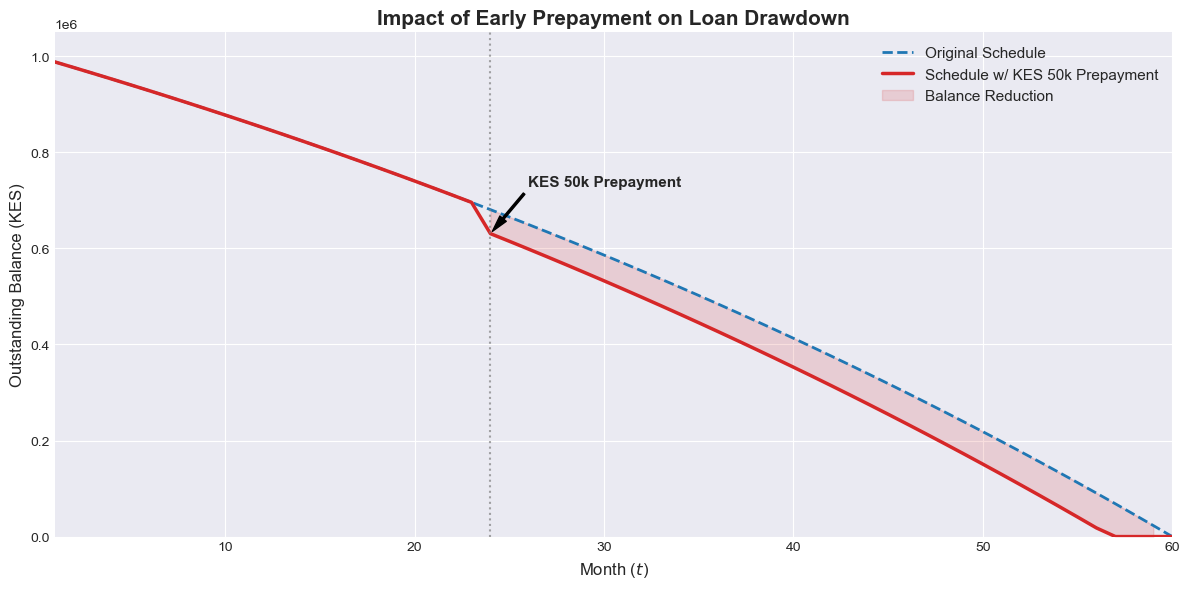

In [2]:
import matplotlib.pyplot as plt

# Set aesthetic styling
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Baseline
ax.plot(base_schedule['Month'], base_schedule['Outstanding_Balance'], 
        label='Original Schedule', color='#1f77b4', linestyle='--', linewidth=2)

# Plot Adjusted Schedule
ax.plot(base_schedule['Month'], base_schedule['Adjusted_Balance'], 
        label='Schedule w/ KES 50k Prepayment', color='#d62728', linewidth=2.5)

# Highlight the prepayment event
ax.axvline(x=prepay_month, color='grey', linestyle=':', alpha=0.7)
ax.annotate('KES 50k Prepayment', 
            xy=(prepay_month, base_schedule['Adjusted_Balance'].iloc[prepay_month-1]), 
            xytext=(prepay_month + 2, base_schedule['Adjusted_Balance'].iloc[prepay_month-1] + 100_000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
            fontsize=11, fontweight='bold')

# Fill the area representing the interest/time saved
ax.fill_between(base_schedule['Month'], 
                base_schedule['Outstanding_Balance'], 
                base_schedule['Adjusted_Balance'], 
                where=(base_schedule['Outstanding_Balance'] > base_schedule['Adjusted_Balance']), 
                color='#d62728', alpha=0.15, label='Balance Reduction')

ax.set_title('Impact of Early Prepayment on Loan Drawdown', fontsize=15, fontweight='bold')
ax.set_xlabel('Month ($t$)', fontsize=12)
ax.set_ylabel('Outstanding Balance (KES)', fontsize=12)
ax.set_xlim(1, months)
ax.set_ylim(0, loan_amount * 1.05)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()